In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.colors
import re
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_excel("/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/INSURANCE/HomeCredit_columns_description.xlsx")

In [4]:
df.head()

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN


In [5]:
try:
    app_train = pd.read_csv('application_train.csv')
    app_test = pd.read_csv('application_test.csv')
except FileNotFoundError:
    print("Data files not found. Using sample data for demonstration.")

    np.random.seed(42)
    sample_size = 1000
    
    app_train = pd.DataFrame({
        'SK_ID_CURR': range(1000, 1000+sample_size),
        'TARGET': np.random.randint(0, 2, size=sample_size),
        'NAME_CONTRACT_TYPE': np.random.choice(['Cash loans', 'Revolving loans'], size=sample_size),
        'CODE_GENDER': np.random.choice(['M', 'F', 'XNA'], size=sample_size, p=[0.5, 0.49, 0.01]),
        'FLAG_OWN_CAR': np.random.choice(['Y', 'N'], size=sample_size),
        'FLAG_OWN_REALTY': np.random.choice(['Y', 'N'], size=sample_size),
        'CNT_CHILDREN': np.random.poisson(0.5, size=sample_size),
        'AMT_INCOME_TOTAL': np.random.lognormal(10, 0.5, size=sample_size),
        'AMT_CREDIT': np.random.lognormal(11, 0.4, size=sample_size),
        'AMT_ANNUITY': np.random.lognormal(9, 0.3, size=sample_size),
        'AMT_GOODS_PRICE': np.random.lognormal(10.5, 0.4, size=sample_size),
        'NAME_INCOME_TYPE': np.random.choice(['Working', 'Commercial associate', 'Pensioner', 'State servant'], 
                                            size=sample_size),
        'NAME_EDUCATION_TYPE': np.random.choice(['Secondary', 'Higher education', 'Incomplete higher', 
                                                'Lower secondary', 'Academic degree'], size=sample_size),
        'DAYS_BIRTH': -np.random.randint(18*365, 70*365, size=sample_size),
        'DAYS_EMPLOYED': np.random.choice([-np.random.randint(0, 40*365), 365243], 
                                        size=sample_size, p=[0.95, 0.05]),
        'EXT_SOURCE_2': np.random.uniform(0, 1, size=sample_size),
        'EXT_SOURCE_3': np.random.uniform(0, 1, size=sample_size)
    })
    
    app_test = app_train.sample(200).drop('TARGET', axis=1)

print("Training data shape:", app_train.shape)
app_train.head()

Data files not found. Using sample data for demonstration.
Training data shape: (1000, 17)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_2,EXT_SOURCE_3
0,1000,0,Revolving loans,M,N,Y,1,19950.931950,34367.017156,11334.310142,31706.453676,State servant,Secondary,-24604,-13149,0.877027,0.110021
1,1001,1,Cash loans,F,Y,Y,0,61941.964493,81270.968493,8134.853512,35719.967248,State servant,Academic degree,-25215,-13149,0.180973,0.559841
2,1002,0,Cash loans,F,Y,Y,1,8814.548521,58615.666094,7678.847059,36601.329601,State servant,Lower secondary,-10459,365243,0.797259,0.246916
3,1003,0,Cash loans,F,Y,Y,2,13021.342801,48031.257630,7840.033219,26344.847237,Commercial associate,Incomplete higher,-7896,-13149,0.456980,0.977145
4,1004,0,Cash loans,F,N,N,1,46570.186542,64036.347845,11939.626443,45778.574704,Working,Secondary,-12471,-13149,0.328272,0.796581


In [6]:
app_train.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_2,EXT_SOURCE_3
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1499.500000,0.51000,0.474000,24285.068181,64036.557433,8411.701837,39469.522380,-16001.931000,10689.696000,0.491475,0.504458
std,288.819436,0.50015,0.697001,12757.102845,26507.194069,2648.640067,17606.610914,5461.648207,91981.242538,0.290363,0.296478
min,1000.000000,0.00000,0.000000,4896.048989,16803.096682,3395.294685,10012.538711,-25538.000000,-13149.000000,0.001334,0.001725
25%,1249.750000,0.00000,0.000000,15236.575547,46022.438406,6525.575624,26925.303197,-20945.750000,-13149.000000,0.235251,0.241285
50%,1499.500000,1.00000,0.000000,21795.570219,59375.617545,7993.008775,35852.982163,-15662.000000,-13149.000000,0.481333,0.497281
75%,1749.250000,1.00000,1.000000,29633.160200,77724.428287,9946.461407,48054.580939,-11328.000000,-13149.000000,0.739979,0.773579
max,1999.000000,1.00000,4.000000,111473.980599,207973.111859,20526.865723,148988.153496,-6586.000000,365243.000000,0.998845,0.997696


In [7]:
app_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   SK_ID_CURR           1000 non-null   int64  
 1   TARGET               1000 non-null   int64  
 2   NAME_CONTRACT_TYPE   1000 non-null   object 
 3   CODE_GENDER          1000 non-null   object 
 4   FLAG_OWN_CAR         1000 non-null   object 
 5   FLAG_OWN_REALTY      1000 non-null   object 
 6   CNT_CHILDREN         1000 non-null   int64  
 7   AMT_INCOME_TOTAL     1000 non-null   float64
 8   AMT_CREDIT           1000 non-null   float64
 9   AMT_ANNUITY          1000 non-null   float64
 10  AMT_GOODS_PRICE      1000 non-null   float64
 11  NAME_INCOME_TYPE     1000 non-null   object 
 12  NAME_EDUCATION_TYPE  1000 non-null   object 
 13  DAYS_BIRTH           1000 non-null   int64  
 14  DAYS_EMPLOYED        1000 non-null   int64  
 15  EXT_SOURCE_2         1000 non-null   fl

In [8]:
print(app_train.columns)

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_2',
       'EXT_SOURCE_3'],
      dtype='object')


In [9]:
print(app_train.dtypes[app_train.dtypes == 'object'])

NAME_CONTRACT_TYPE     object
CODE_GENDER            object
FLAG_OWN_CAR           object
FLAG_OWN_REALTY        object
NAME_INCOME_TYPE       object
NAME_EDUCATION_TYPE    object
dtype: object


In [10]:
df_encoded = pd.get_dummies(app_train, dtype='float64')
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SK_ID_CURR                             1000 non-null   int64  
 1   TARGET                                 1000 non-null   int64  
 2   CNT_CHILDREN                           1000 non-null   int64  
 3   AMT_INCOME_TOTAL                       1000 non-null   float64
 4   AMT_CREDIT                             1000 non-null   float64
 5   AMT_ANNUITY                            1000 non-null   float64
 6   AMT_GOODS_PRICE                        1000 non-null   float64
 7   DAYS_BIRTH                             1000 non-null   int64  
 8   DAYS_EMPLOYED                          1000 non-null   int64  
 9   EXT_SOURCE_2                           1000 non-null   float64
 10  EXT_SOURCE_3                           1000 non-null   float64
 11  NAME_

In [11]:
print(df_encoded.columns)

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'NAME_CONTRACT_TYPE_Cash loans', 'NAME_CONTRACT_TYPE_Revolving loans',
       'CODE_GENDER_F', 'CODE_GENDER_M', 'CODE_GENDER_XNA', 'FLAG_OWN_CAR_N',
       'FLAG_OWN_CAR_Y', 'FLAG_OWN_REALTY_N', 'FLAG_OWN_REALTY_Y',
       'NAME_INCOME_TYPE_Commercial associate', 'NAME_INCOME_TYPE_Pensioner',
       'NAME_INCOME_TYPE_State servant', 'NAME_INCOME_TYPE_Working',
       'NAME_EDUCATION_TYPE_Academic degree',
       'NAME_EDUCATION_TYPE_Higher education',
       'NAME_EDUCATION_TYPE_Incomplete higher',
       'NAME_EDUCATION_TYPE_Lower secondary', 'NAME_EDUCATION_TYPE_Secondary'],
      dtype='object')


In [12]:
columns_to_drop = ['NAME_CONTRACT_TYPE_Cash loans', 'NAME_CONTRACT_TYPE_Revolving loans',
       'CODE_GENDER_F', 'CODE_GENDER_M', 'CODE_GENDER_XNA', 'FLAG_OWN_CAR_N',
       'FLAG_OWN_CAR_Y', 'FLAG_OWN_REALTY_N', 'FLAG_OWN_REALTY_Y',
       'NAME_INCOME_TYPE_Commercial associate', 'NAME_INCOME_TYPE_Pensioner',
       'NAME_INCOME_TYPE_State servant', 'NAME_INCOME_TYPE_Working',
       'NAME_EDUCATION_TYPE_Academic degree',
       'NAME_EDUCATION_TYPE_Higher education',
       'NAME_EDUCATION_TYPE_Incomplete higher',
       'NAME_EDUCATION_TYPE_Lower secondary', 'NAME_EDUCATION_TYPE_Secondary']

df_encoded = df_encoded.drop(columns=columns_to_drop)

In [13]:
df_encoded.info()
#'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL','AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_INCOME_TYPE','NAME_EDUCATION_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_2','EXT_SOURCE_3'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SK_ID_CURR        1000 non-null   int64  
 1   TARGET            1000 non-null   int64  
 2   CNT_CHILDREN      1000 non-null   int64  
 3   AMT_INCOME_TOTAL  1000 non-null   float64
 4   AMT_CREDIT        1000 non-null   float64
 5   AMT_ANNUITY       1000 non-null   float64
 6   AMT_GOODS_PRICE   1000 non-null   float64
 7   DAYS_BIRTH        1000 non-null   int64  
 8   DAYS_EMPLOYED     1000 non-null   int64  
 9   EXT_SOURCE_2      1000 non-null   float64
 10  EXT_SOURCE_3      1000 non-null   float64
dtypes: float64(6), int64(5)
memory usage: 86.1 KB


In [14]:
print(df_encoded.columns.tolist())

['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_2', 'EXT_SOURCE_3']


In [15]:
df_encoded.head()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_2,EXT_SOURCE_3
0,1000,0,1,19950.931950,34367.017156,11334.310142,31706.453676,-24604,-13149,0.877027,0.110021
1,1001,1,0,61941.964493,81270.968493,8134.853512,35719.967248,-25215,-13149,0.180973,0.559841
2,1002,0,1,8814.548521,58615.666094,7678.847059,36601.329601,-10459,365243,0.797259,0.246916
3,1003,0,2,13021.342801,48031.257630,7840.033219,26344.847237,-7896,-13149,0.456980,0.977145
4,1004,0,1,46570.186542,64036.347845,11939.626443,45778.574704,-12471,-13149,0.328272,0.796581


In [16]:
y = df_encoded['TARGET']
X = df_encoded.drop('TARGET', axis=1)
X = pd.get_dummies(X)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

In [19]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

lin_reg.fit(X_train, y_train)

predictions = lin_reg.predict(X_test)

print("Intercept:",lin_reg.intercept_)
print("Coefficients:",lin_reg.coef_)

Intercept: 0.5914708371481442
Coefficients: [-4.16655253e-05 -1.52076384e-02  7.99581608e-07  7.00257144e-09
  3.65875060e-06  2.25091246e-06  2.60202066e-06 -7.73157729e-08
 -1.37687359e-01 -8.44016171e-02]


In [20]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Regression Coefficient: [-4.16655253e-05 -1.52076384e-02  7.99581608e-07  7.00257144e-09
  3.65875060e-06  2.25091246e-06  2.60202066e-06 -7.73157729e-08
 -1.37687359e-01 -8.44016171e-02]
Standard Deviation (RMSE): 0.5036252638893888
R-squared: -0.01709636662719416


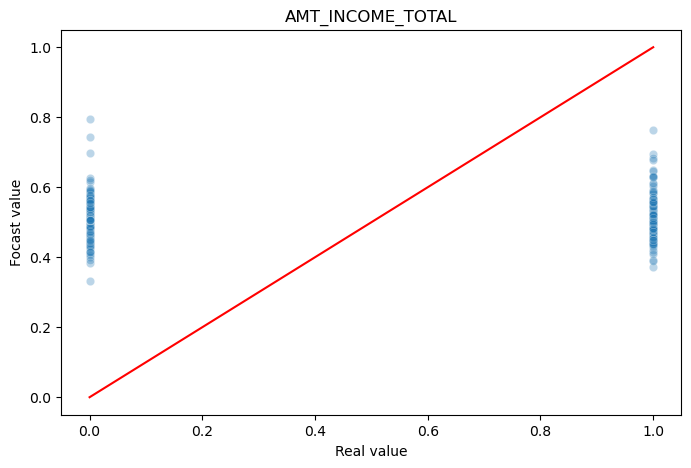

In [21]:
y_pred = model.predict(X_test)

print("Regression Coefficient:", model.coef_)
print("Standard Deviation (RMSE):", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared:", r2_score(y_test, y_pred))

plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.xlabel("Real value")
plt.ylabel("Focast value")
plt.title("AMT_INCOME_TOTAL")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.show()

In [22]:
X = sm.add_constant(X)

In [23]:
model = sm.OLS(y, X).fit()

In [24]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 TARGET   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.413
Date:                Wed, 04 Jun 2025   Prob (F-statistic):              0.169
Time:                        08:22:10   Log-Likelihood:                -718.50
No. Observations:                1000   AIC:                             1459.
Df Residuals:                     989   BIC:                             1513.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.5662      0.129  

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [26]:
if 'CODE_GENDER' in df_encoded.columns:
    df_encoded['CODE_GENDER'] = df_encoded['CODE_GENDER'].map({'M': 1, 'F': 0})

columns_to_maps = ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_MOBIL', 'FLAG_EMP_PHONE',
                  'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL']
for col in columns_to_maps:
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].map({'Y': 1, 'N': 0})

In [27]:
X = df_encoded[['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_2', 'EXT_SOURCE_3']]
y = df_encoded['TARGET']
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [28]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# create pipeline - xử lý dữ liệu
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  # replace missing values by median
    ('scaler', StandardScaler())  # chuẩn hoá
])

X_processed = preprocessor.fit_transform(X)

In [29]:
# Chia dữ liệu theo nhãn
class_0 = df_encoded[df_encoded['TARGET'] == 0]
class_1 = df_encoded[df_encoded['TARGET'] == 1]

# Tăng lớp thiểu số lên bằng lớp đa số
class_1_oversampled = class_1.sample(len(class_0), replace=True, random_state=42)

# Gộp lại
df_balanced = pd.concat([class_0, class_1_oversampled]).sample(frac=1, random_state=42)

# Tách lại X, y
X = df_balanced[['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_2', 'EXT_SOURCE_3']]
y = df_balanced['TARGET']

In [30]:
from sklearn.utils.class_weight import compute_class_weight

# Tính trọng số cho từng lớp
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# Đưa vào model
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500, class_weight=class_weight_dict)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight={0: 1.0126582278481013, 1: 0.9876543209876543},
                   max_iter=500, multi_class='multinomial')

In [32]:
y_pred = model.predict(X_test)

In [33]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix:
[[153   0]
 [  0 141]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       1.00      1.00      1.00       141

    accuracy                           1.00       294
   macro avg       1.00      1.00      1.00       294
weighted avg       1.00      1.00      1.00       294

Accuracy: 1.0


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


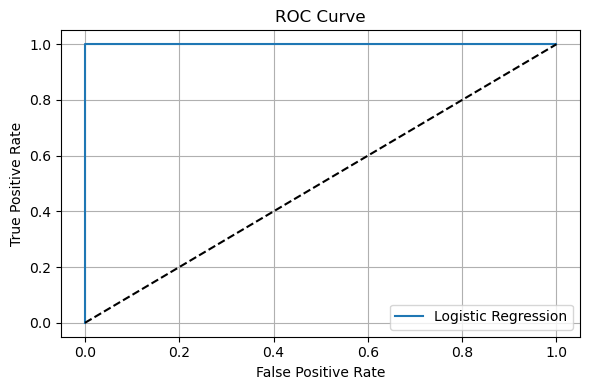

AUC Score: 1.0


In [34]:
features = ['CNT_CHILDREN', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE']  

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train, y_train)

# Predict proba
y_proba = log_model.predict_proba(X_test)[:, 1]

# ROC/AUC
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("AUC Score:", roc_auc_score(y_test, y_proba))